In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

In [4]:
print(df.head())
print(df.shape)
print(df['species'].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
(150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


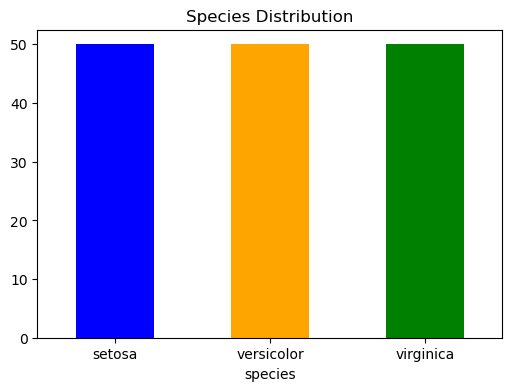

In [6]:
# Species Distribution
plt.figure(figsize=(6,4))
df['species'].value_counts().plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title("Species Distribution")
plt.xticks(rotation=0)
plt.show()

C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

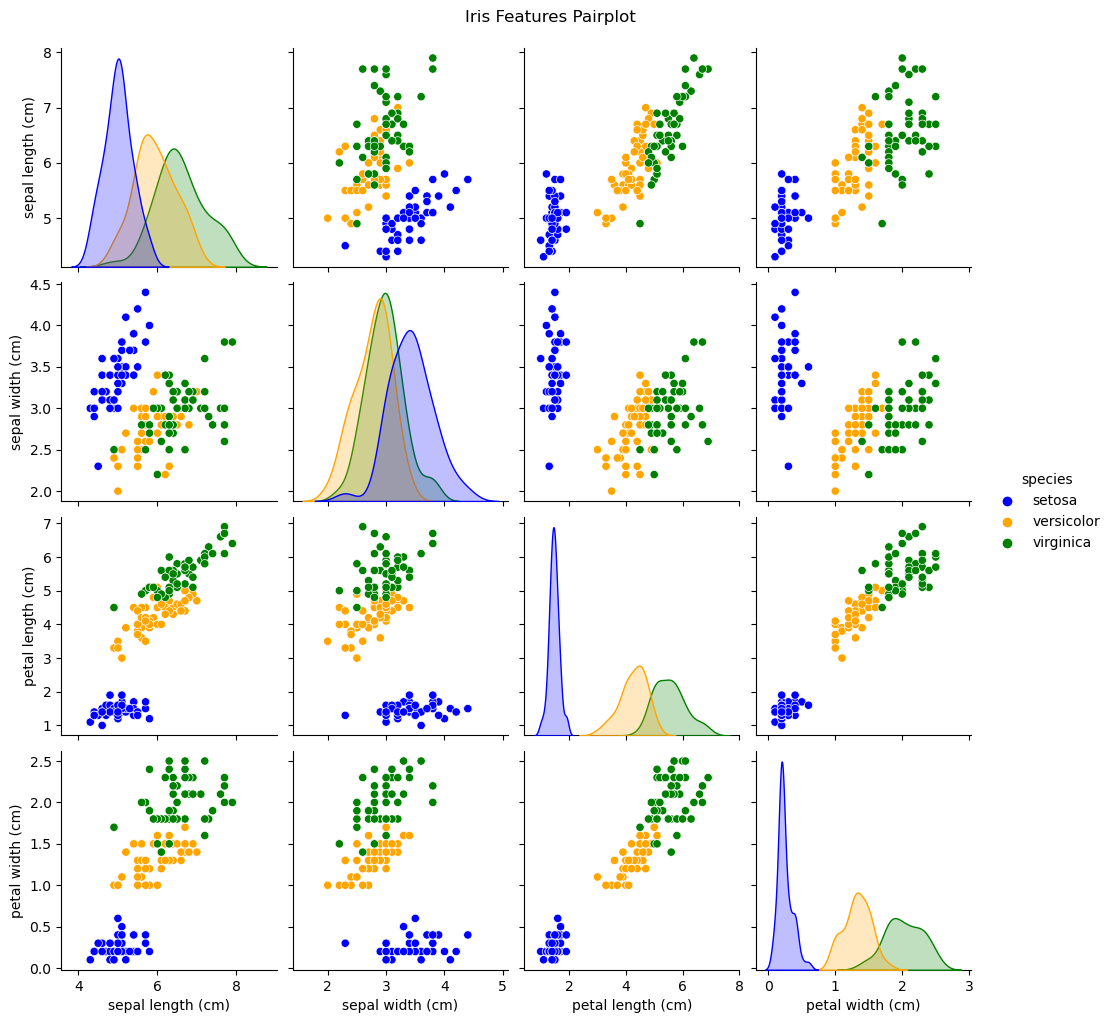

In [8]:
# Pairplot to see how features separate species
sns.pairplot(df, hue='species', palette=['blue', 'orange', 'green'])
plt.suptitle('Iris Features Pairplot', y=1.02)
plt.show()

In [9]:
# Prepare features and target
X = df.drop('species', axis=1)
y = df['species']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23 )

In [11]:
# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=23)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=23)

In [12]:
# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:", classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667

Classification Report:               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.89      1.00      0.94         8
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



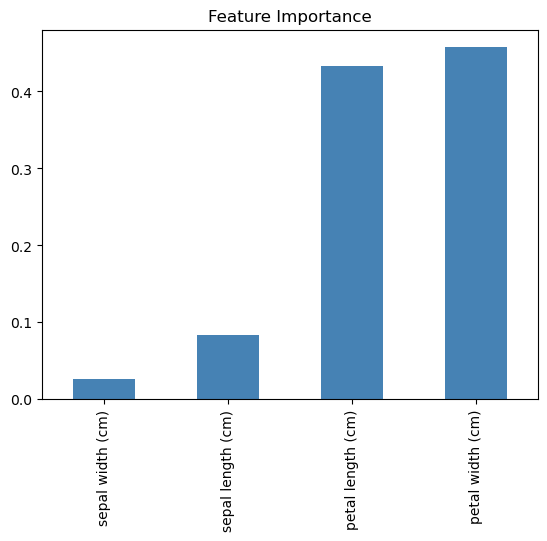

In [14]:
# Feature Importance
fe_import = pd.Series(model.feature_importances_, index=X.columns)
fe_import.sort_values().plot(kind='bar', color='steelblue')
plt.title("Feature Importance")
plt.show()